# Title 

## Introduction 
- wendy
- provide some relevant background information on the topic so that someone unfamiliar with it will be prepared to understand the rest of your report
- clearly state the question you tried to answer with your project
- identify and fully describe the dataset that was used to answer the question


## Question 

Broad Question: Question 1 

Specific Question: Is age and played_hours a good predictor of the subscription status of a game-related newsletter? 

## Methods & Results 

- describe the methods you used to perform your analysis from beginning to end that narrates the analysis code.
- your report should include code which:
  
- terence 
    - loads data
    - wrangles and cleans the data to the format necessary for the planned analysis
    - performs a summary of the data set that is relevant for exploratory data analysis related to the planned analysis
    - creates a visualization of the dataset that is relevant for exploratory data analysis related to the planned analysis

together (plan a call in future): 

    - performs the data analysis
    - creates a visualization of the analysis
    - note: all figures should have a figure number and a legend


3. Exploratory Data Analysis

Firstly, the *repr* and *tidyverse* package is loaded into jupyter for obtaining the tools necessary for data analysis and wrangling.

In [18]:
library(repr)
library(tidyverse)
library(tidymodels)
options(repr.matrix.max.rows = 5) #limited dataframes to only show the first 5 rows for legibility

### 1. Loads data

In [19]:
players <- read_csv("data/players.csv")

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


### 2. Wrangles and cleans the data

In [20]:
players_tidy <- players |>
mutate(experience=as.factor(Age),
       subscribe=as.factor(subscribe),
       gender=as.factor(gender))|>
drop_na()

players_tidy

experience,subscribe,hashedEmail,played_hours,name,gender,Age
<fct>,<fct>,<chr>,<dbl>,<chr>,<fct>,<dbl>
9,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
17,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
17,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
⋮,⋮,⋮,⋮,⋮,⋮,⋮
57,FALSE,d572f391d452b76ea2d7e5e53a3d38bfd7499c7399db299bd4fedb06a46ad5bb,0.0,Dylan,Prefer not to say,57
17,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17


### 3. Performs a summary of the data set

In [34]:
players_age_summary <- players |>
select(Age)|>
summarize(players_age_max=max(Age,na.rm=TRUE),
          players_age_min=min(Age,na.rm=TRUE))

players_age_summary

played_hours_summary <- players |>
select(played_hours)|>
summarize(played_hours_min=min(played_hours,na.rm=TRUE),
          played_hours_max=max(played_hours,na.rm=TRUE))

played_hours_summary

players_mean <- players_tidy |>
select(played_hours,Age)|>
summarize(played_hours_avg=mean(played_hours),
          players_age_avg=mean(Age))|>
mutate(played_hours_avg = round(played_hours_avg, 2),
       players_age_avg = round(players_age_avg, 2))

players_mean

players_age_max,players_age_min
<dbl>,<dbl>
58,9


played_hours_min,played_hours_max
<dbl>,<dbl>
0,223.1


played_hours_avg,players_age_avg
<dbl>,<dbl>
5.9,21.14


### 4. Visualization

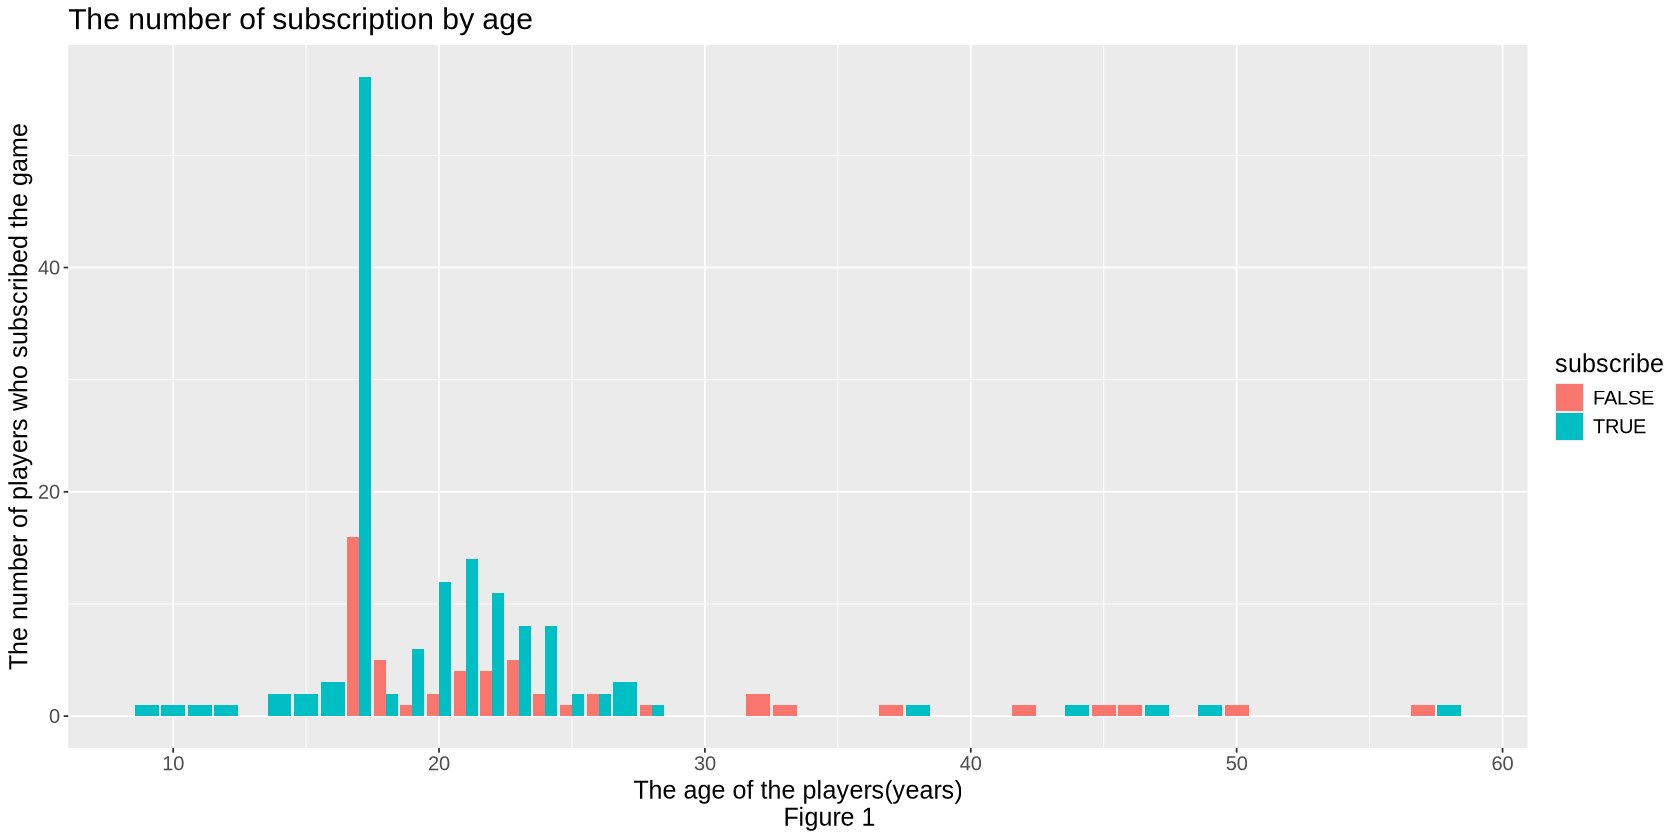

In [35]:
options(repr.plot.height=7, repr.plot.width=14)

players_age_plot_1 <- players_tidy |>
select(Age,subscribe)|>
ggplot(aes(x = Age, fill = subscribe)) + 
   geom_bar(position = "dodge") +
   scale_x_continuous(breaks = seq(0,60,by=10))+
   labs(x = "The age of the players(years)
         Figure 1" ,
        y = "The number of players who subscribed the game",
        title = "The number of subscription by age")+
   theme(text=element_text(size=15))

players_age_plot_1

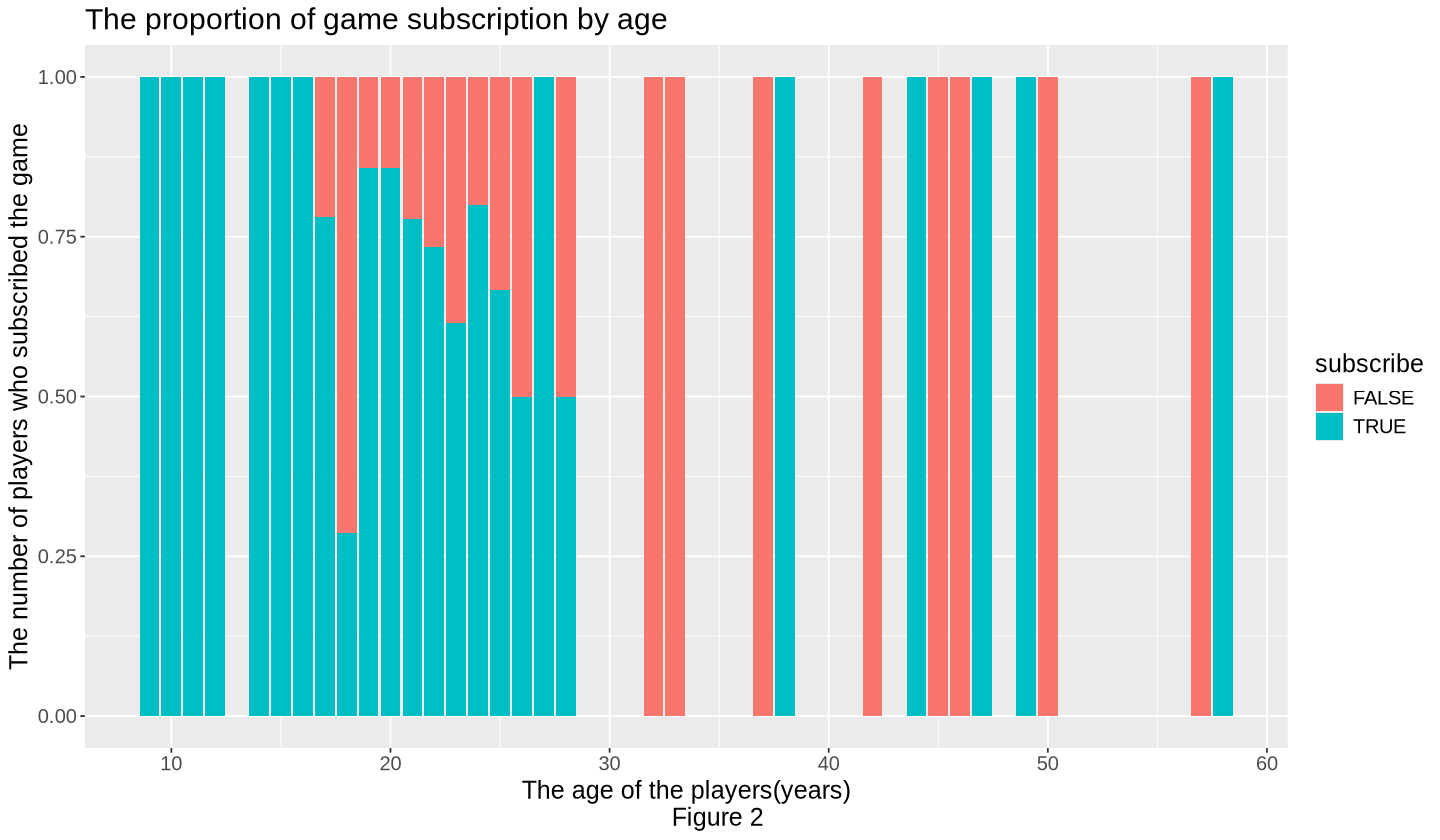

In [36]:
options(repr.plot.width=12, repr.plot.height=7)

players_plot_2 <- players_tidy |>
select(Age,subscribe)|>
ggplot(aes(x = Age, fill = subscribe)) + 
   geom_bar(position = "fill") +
   scale_x_continuous(breaks = seq(0,60,by=10))+
   labs(x = "The age of the players(years)
         Figure 2" ,
        y = "The number of players who subscribed the game",
        title = "The proportion of game subscription by age")+
   theme(text=element_text(size=15))

players_plot_2

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


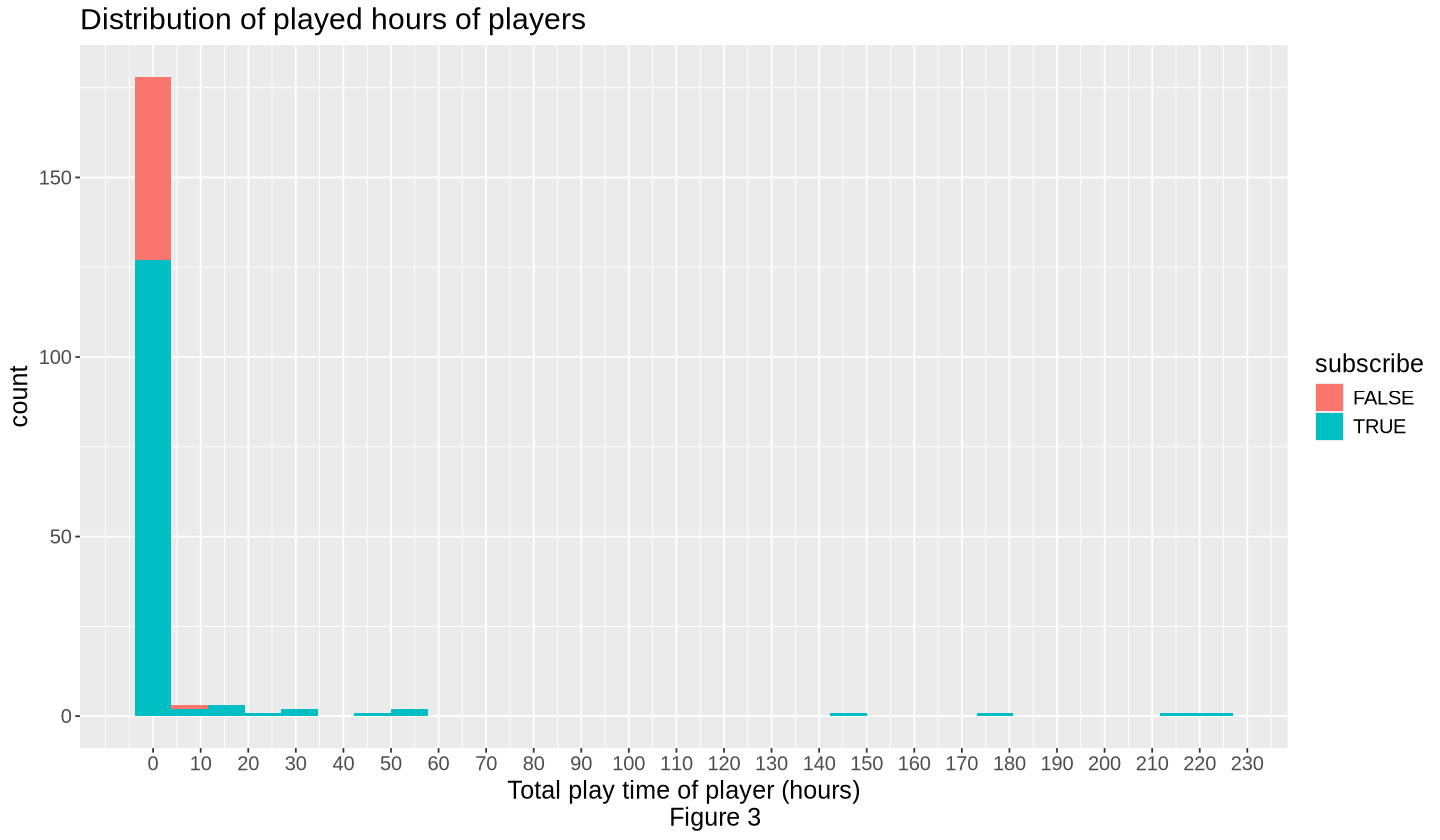

In [37]:
players_hrs_plot <- players_tidy |>
    ggplot(aes(x=played_hours, fill= subscribe)) +
    geom_histogram() +
    labs(x= "Total play time of player (hours)
         Figure 3", 
         color= "Whether a player is subscribed", 
         title = "Distribution of played hours of players") +
scale_x_continuous(breaks = seq(0,250,by=10))+
    theme(text = element_text(size=15))

players_hrs_plot

## Data analysis

Next, create a scatterplot to explore the relationship between the predictors and the target variable.

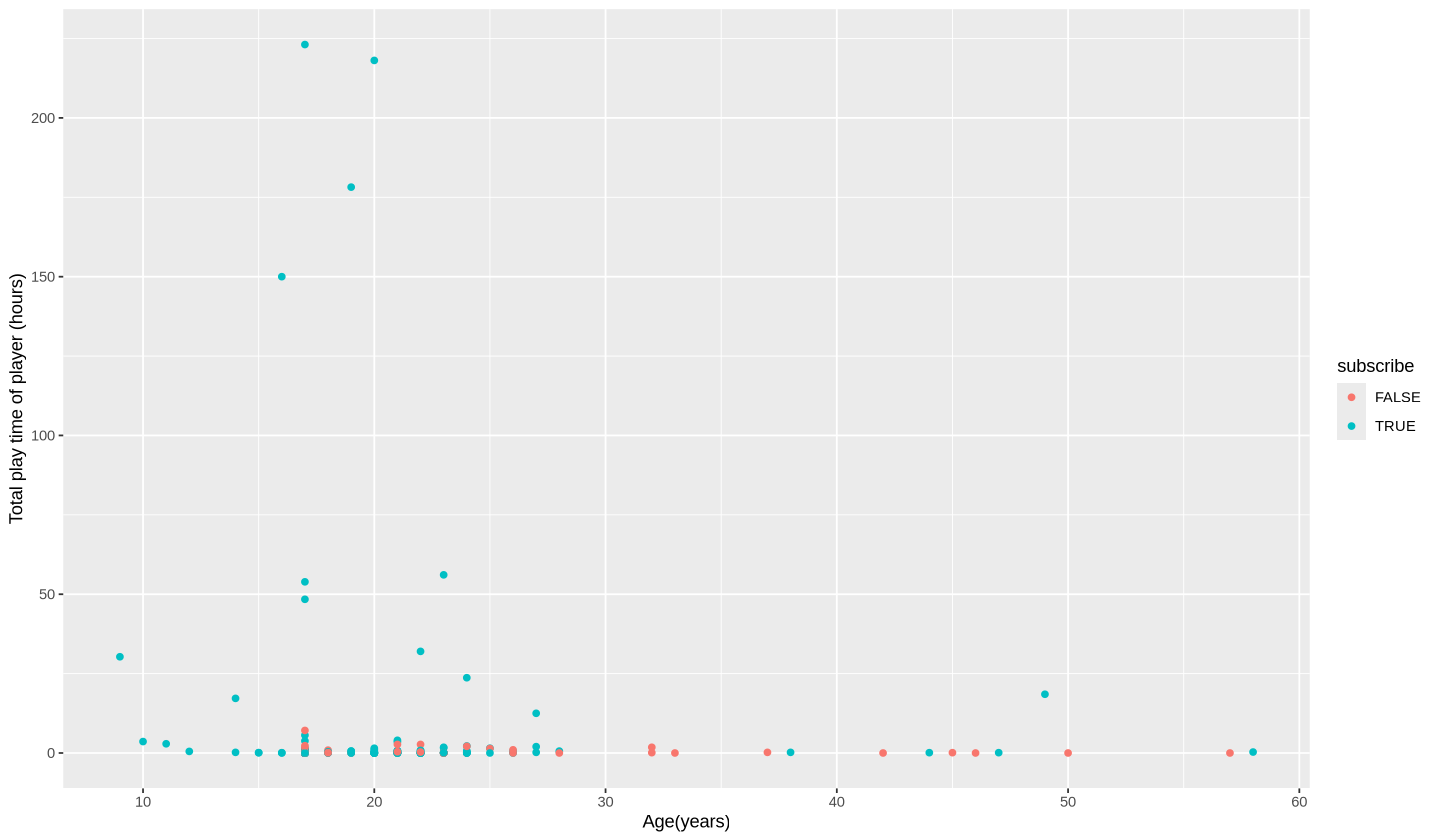

In [38]:
ggplot(players_tidy,aes(x=Age, y=played_hours, color=subscribe))+
geom_point()+
labs(x="Age(years)", 
     y="Total play time of player (hours)")

Next, split the data into training data and testing data. 

I will use 75% of the data for training and 25% for testing.The subset of training data used for evaluation is the validation set. And then I will use it for cross-validation.

In [39]:
players_split <- initial_split(players_tidy,prop=0.75, strata=subscribe)

players_train <- training(players_split)
players_test <- testing(players_split)

Next, we use cross-validation on the training data set to select which k is the most optimal for our data set for k-nn classification.

we will :
- Create a recipe that uses all predictors and a model specification with tuning on the number of neighbours 
- Perform a 5-fold cross-validation on the training set
- Create a workflow analysis with your recipe and model specification. 
- Collect the metrics from the workflow analysis
- Plot the accuracy vs k, assign this plot to an object called cross_val_plot

In [43]:
set.seed(9999) 

players_recipe <- recipe(subscribe ~ Age + played_hours, data = players_train)|>
     step_scale(all_predictors()) |>
     step_center(all_predictors())

players_vfold <- vfold_cv(players_train, v = 5, strata = subscribe)

players_model <- nearest_neighbor(weight_func="rectangular", neighbors = tune())|>
   set_engine("kknn")|>
   set_mode("classification")

k_vals <- tibble(neighbors = seq(from = 1, to = 100, by = 5))

players_workflow <- workflow()|>
    add_model(players_model)|>
    add_recipe(players_recipe)|>
    tune_grid(resamples = players_vfold, grid = k_vals) |>
    collect_metrics()

players_workflow

neighbors,.metric,.estimator,mean,n,std_err,.config
<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
1,accuracy,binary,0.4491790,5,0.03643054,Preprocessor1_Model01
1,roc_auc,binary,0.4913420,5,0.05305480,Preprocessor1_Model01
6,accuracy,binary,0.5581445,5,0.02940245,Preprocessor1_Model02
⋮,⋮,⋮,⋮,⋮,⋮,⋮
96,accuracy,binary,0.7311494,5,0.005037841,Preprocessor1_Model20
96,roc_auc,binary,0.4909246,5,0.050844370,Preprocessor1_Model20


In [44]:
accuracies <- players_workflow |>
  filter(.metric == "accuracy")

accuracies

neighbors,.metric,.estimator,mean,n,std_err,.config
<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
1,accuracy,binary,0.4491790,5,0.03643054,Preprocessor1_Model01
6,accuracy,binary,0.5581445,5,0.02940245,Preprocessor1_Model02
11,accuracy,binary,0.6276026,5,0.04771193,Preprocessor1_Model03
⋮,⋮,⋮,⋮,⋮,⋮,⋮
91,accuracy,binary,0.7311494,5,0.005037841,Preprocessor1_Model19
96,accuracy,binary,0.7311494,5,0.005037841,Preprocessor1_Model20


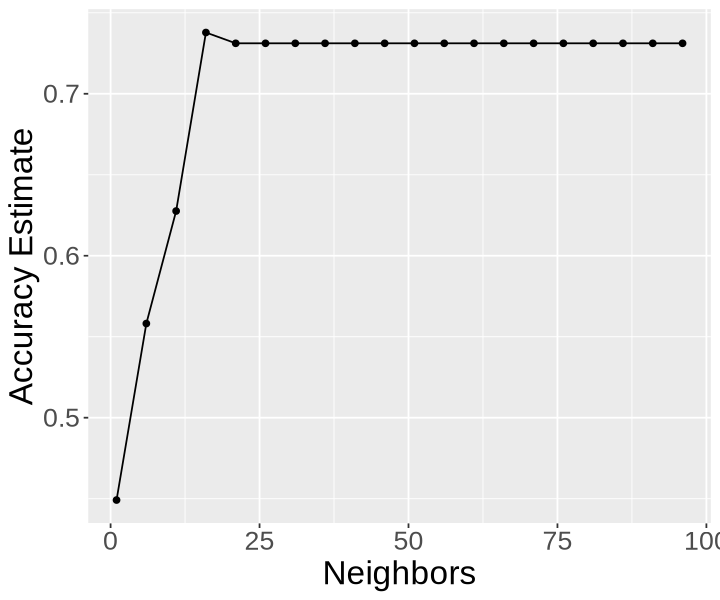

In [45]:
options(repr.plot.height = 5, repr.plot.width = 6)

cross_val_plot <- ggplot(accuracies, aes(x = neighbors, y = mean)) +
                  geom_point() +
                  geom_line() +
                  labs(x = 'Neighbors', y = 'Accuracy Estimate') +
                  theme(text = element_text(size = 20)) 

cross_val_plot

In [46]:
best_k <- accuracies |>
        arrange(desc(mean)) |>
        head(1) |>
        pull(neighbors)
best_k

[1] 16

### Evaluating on the test set

In [47]:
players_recipe <- recipe(subscribe ~ Age + played_hours, data = players_train)|>
     step_scale(all_predictors()) |>
     step_center(all_predictors())

players_model <- nearest_neighbor(weight_func="rectangular", neighbors = best_k)|>
   set_engine("kknn")|>
   set_mode("classification")

players_fit <- workflow() |>
  add_recipe(players_recipe) |>
  add_model(players_model) |>
  fit(data = players_train)

players_fit

══ Workflow [trained] ══════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: nearest_neighbor()

── Preprocessor ────────────────────────────────────────────────────────────────
2 Recipe Steps

• step_scale()
• step_center()

── Model ───────────────────────────────────────────────────────────────────────

Call:
kknn::train.kknn(formula = ..y ~ ., data = data, ks = min_rows(16,     data, 5), kernel = ~"rectangular")

Type of response variable: nominal
Minimal misclassification: 0.2758621
Best kernel: rectangular
Best k: 16

In [48]:
players_test_predictions <- predict(players_fit, players_test) |>
  bind_cols(players_test)

players_test_predictions |>
  metrics(truth = subscribe, estimate = .pred_class) |>
  filter(.metric == "accuracy")

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.7346939


## Discussion 
- chloe: summarize what you found
- merry: discuss whether this is what you expected to find
- terence: discuss what impact could such findings have
- wendy: discuss what future questions could this lead to



### 1. Summary of data analysis

#### 1.1 visualization
- Figure 1:

  
This bar chart compares the subscription status of players across different ages. As for 17-year-old players, they have the highest number of both subscribed and non-subscribed players, representing by far the highest figures.
  
- Figure 2:
  
This bar chart compares the proportion of players who subscribed across different age groups. It is clear that players around or under 15 years old all subscribed the game. For younger players (under 30), they are generally more likely to subscribe, but also a lot of them did not, especially those aged 18 that only has approximately 30% subscribed to the game.

By contrast, players above 30 display a fairly balanced subscription patterns, with roughly equal subscribed and non-subscribed.

Overall, while younger players include many non-subscribers, they also make up the majority of the dataset, representing strong engagement potential.

- Figure 3:
  
This histogram shows the distribution of the played hours of players. According to the histogram, all players with more than 10 hours played time subscribed to the game, representing players who spend more time playing are more likely to subscribe indeed.

However, as for those players with 10 or fewer player hours, approximately 70% also subscribed, suggesting that many short players still subscribed the game.

Overall, whereas played hours affects the subscription behavior in some way, they do not seem to be the dominant factor driving whether a player subscribe.

#### 1.2 method
- The classification is appropriate because the response variable (subscribe) is a categorical type.
- The K-nearest neighbors (KNN) algorithm can be used here because it can use data directly to form the class by measuring the proximity to neighboring points to determine the class of a new sample.
- K-nearest neighbors (KNN) algorithm requires few assumptions about what the data must look like. It can essentially captures any kind of shape of data for a class.
- Use cross-validation to give a better choice of the number of neighbors K for the overall set of training data. A K of 16 gives us the best accuracy which is 0.73(round to 2 decimal places). We can be sure as cross-validation attempts to give us an unbiased estimate of the k by splitting the data in multiple parts and using the average of the multiple splits as the estimate.
- Our accuracy was about 70%, this means that about 30% of the time our classifier makes a mistake which is likely too low. For the improvements, we might want to include more data. We could also explore if there are additional parameters to tune that could improve model performance, or a different model altogether.

#### 1.3  strengths and weaknesses for K-nearest neighbors classification
Strengths: 
- is a simple, intuitive algorithm,
- requires few assumptions about what the data must look like, and
- works for binary (two-class) and multi-class (more than 2 classes) classification problems.

Weaknesses: 
- becomes very slow as the training data gets larger,
- may not perform well with a large number of predictors, and
- may not perform well when classes are imbalanced.

## References 
You may include references if necessary, as long as they all have a consistent citation style.